<a href="https://colab.research.google.com/github/KarinaDVI/1822-Almacenando-Datos-En-El-Navegador/blob/projectoInicial/Copia_de_Copia_de_entrega_1_IAA_para_mi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consignas:
1. **Grupo: 16**
*   Integrante: Oriana Paz
*   e-mail: olpaz@estudiantes.unsam.edu.ar
*   Integrante: Karina Beatriz Bouza
*   e-mail: kbouza@gmail.com
*   Integrante: Matias Kronemberger
*   e-mail: matikrone@gmail.com

# Predicción de Egreso y Éxito Académico Estudiantil


# Descripcion del conjunto de datos

<font face="Calibri" size=5 color='#00000'> El conjunto de datos utilizado proviene del repositorio de Machine Learning de la Universidad de California en Irvine (UCI):
*   https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success


<font face="Calibri" size=5 color='#00000'>Este dataset contiene información demográfica, socioeconómica y académica de estudiantes de una institución educativa portuguesa. Entre las variables se incluyen: el rendimiento académico en el primer y segundo semestre, antecedentes educativos, situación económica y otras características personales. Los datos fueron previamente analizados para eliminar valores faltantes y atípicos, por esa razón no se requiere ningún preprocesamiento de datos.

### Exploración del conjunto de datos
Para explorar mis datos, importo las librerías necesarias y le otorgo permiso de utilizar archivos de mi Drive.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive

In [ ]:
estudiantes = pd.read_csv('data.csv', sep=';')

Este dataset cuenta con 4424 instancias y 37 variables.

In [ ]:
estudiantes.shape

(4424, 37)

En la página donde se obtuvo el dataset, nos indica que los datos se preprocesaron para manejar los outliers y valores atípicos o faltantes. No contiene datos faltantes

In [ ]:
estudiantes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

Ahora continuamos analizando las variables presentes. Contamos con 29 de tipo int, 7 tipo float y 1 object. Excepto la variable *target*, todas las columnas son de tipo númerico.

A pesar de tener tantas variables numéricas, contamos con muchas variables categóricas interesantes como:
* Marital status: estado civil
* Application mode: método de aplicación del estudiante
* Course: curso tomado por el estudiante
* Daytime/evening attendance: si cursa durante el día o la noche
* Nacionality: nacionalidad del estudiante
* Mother's qualification: cualificación de la madre
* Father's qualification: cualificación del padre
* Educational special needs: si tiene una necesidad educativa especial
* Debtor: si es deudor
* Gender: género
* Scholarship holder: si está becado
* International: si es un estudiante de otro país


### 4.
El objetivo sería averiguar la probabilidad de que un alumno se reciba en tiempo y forma, es decir al finalizar los dos semestres.
Partiendo de la variable "Target", la idea sería simplificarla graduado o no graduado. Por lo que se utilizará un problema de **clasificación**.

Independientemente del modelo elegido al final, nuestras métricas serán:
* Accuracy: proporción de datos correctamente clasificados.
* Curva ROC: representación del TPR (True Positive Rate) vs. el FPR (False Positive Rate) para cada valor del umbral.

In [ ]:
targets_unicos = estudiantes['Target'].unique()

for i, target in enumerate(estudiantes['Target']):
  if target == 'Graduate':
    estudiantes.loc[estudiantes['Target'] == target, 'Graduado'] = 'Si'
  elif target in ['Dropout', 'Enrolled']:
    estudiantes.loc[estudiantes['Target'] == target, 'Graduado'] = 'No'
  else:
    print(f"Unexpected target value: {target}")

estudiantes['Graduado']

,Graduado
0,No
1,Si
2,No
3,Si
4,Si
...,...
4419,Si
4420,No
4421,No
4422,Si


In [ ]:
estudiantes["Graduado"].value_counts()

,count
Graduado,
No,2215
Si,2209


### 5.
Los atributos que consideramos como buenos predictores son los grados obtenidos al final del primer y segundo semestre, ya que los que tienen los valores más altos son quienes finalmente se gradúan.

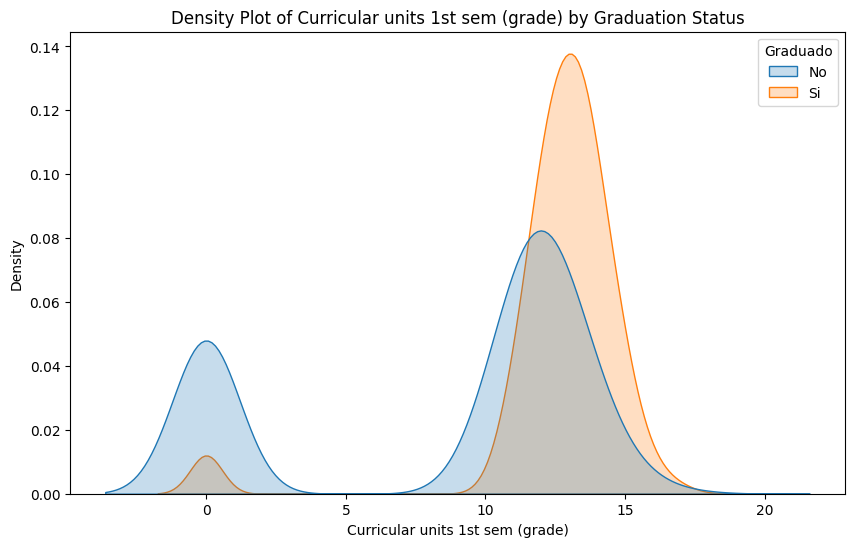

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=estudiantes, x='Curricular units 1st sem (grade)', hue='Graduado', fill=True)
plt.xlabel('Curricular units 1st sem (grade)')
plt.ylabel('Density')
plt.title('Density Plot of Curricular units 1st sem (grade) by Graduation Status')
plt.show()

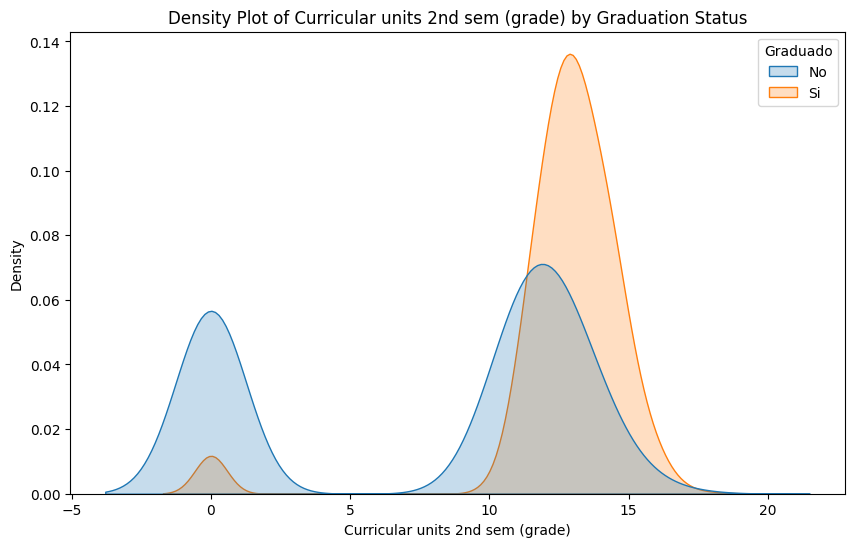

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=estudiantes, x='Curricular units 2nd sem (grade)', hue='Graduado', fill=True)
plt.xlabel('Curricular units 2nd sem (grade)')
plt.ylabel('Density')
plt.title('Density Plot of Curricular units 2nd sem (grade) by Graduation Status')
plt.show()

En el eje x, se encuentran el promedio de la nota al finalizar el primer y segundo semestre respectivamente. Se eligió usar gráficos de densidad porque en ambos semestres hay una gran cantidad de alumnos que promedian 0 al final.

Para ambos gráficos, se observa que la mayoría de alumnos que tienen un promedio entre 10 y 14 son finalmente los que se gradúan mientras que los que alcanzan un promedio entre 10 y 13 no lo terminan haciendo. El promedio de la nota al final del semestre se encuentra entre 0 y 20.



---



# Segunda entrega

2. Elaborar un resumen de hasta 100 palabras que plantee los objetivos del trabajo, y los logros que consideran alcanzados hasta esta entrega.

Con este trabajo se busca investigar sobre la probabilidad de que un alumno se gradue en tiempo y forma. En los casos en los que no sucede, nos interesa conocer los factores que contribuyen al abandono académico para así poder pensar y proponer políticas que eviten que los alumnos dejen sus carreras.

Con la primera entrega, hemos descrito y analizado el conjunto de datos, como así también mostrado el problema de clasificación de interés. Propusimos la variable target y la convertimos en binaria, luego demostramos posibles métricas y variables predictoras para el futuro modelo que usaremos.

3. Proponer un modelo de referencia (benchmark). ¿Qué desempeño tiene dicho modelo? El benchmark es un modelo simple, de fácil interpretación, que fija un desempeño mínimo contra el que comparar a los sucesivos modelos de creciente complejidad.

Arbol de decision (binario)

Importamos la libreria, separamos entre entrenamiento y testeo y luego entrenamos el arbol de decision

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=2, random_state = 42)
X = estudiantes[['Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)']]
y = estudiantes['Graduado']
y = y.map({'No': 0, 'Si': 1})

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

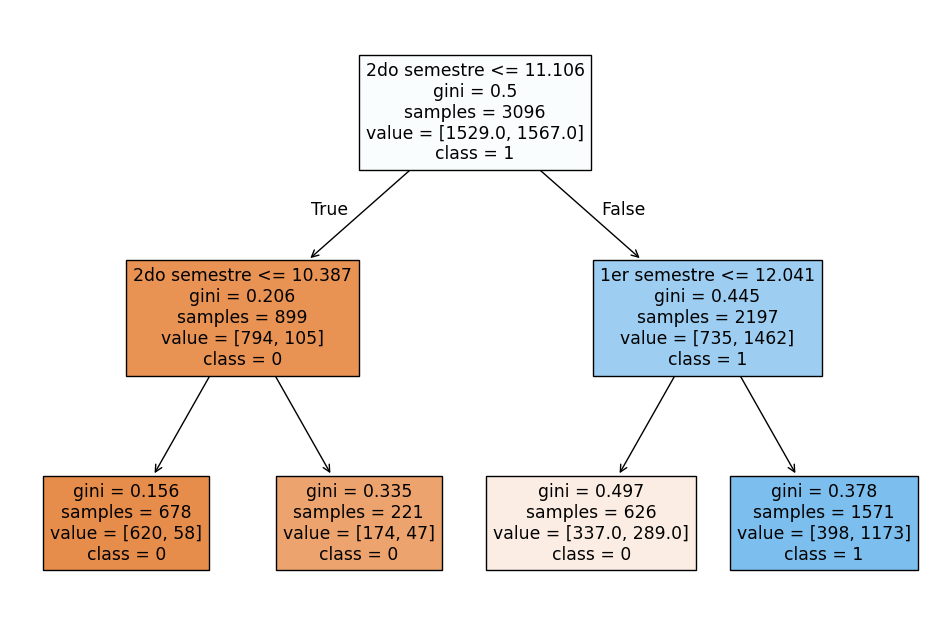

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=['1er semestre', '2do semestre'], class_names=['0', '1'])
plt.show()

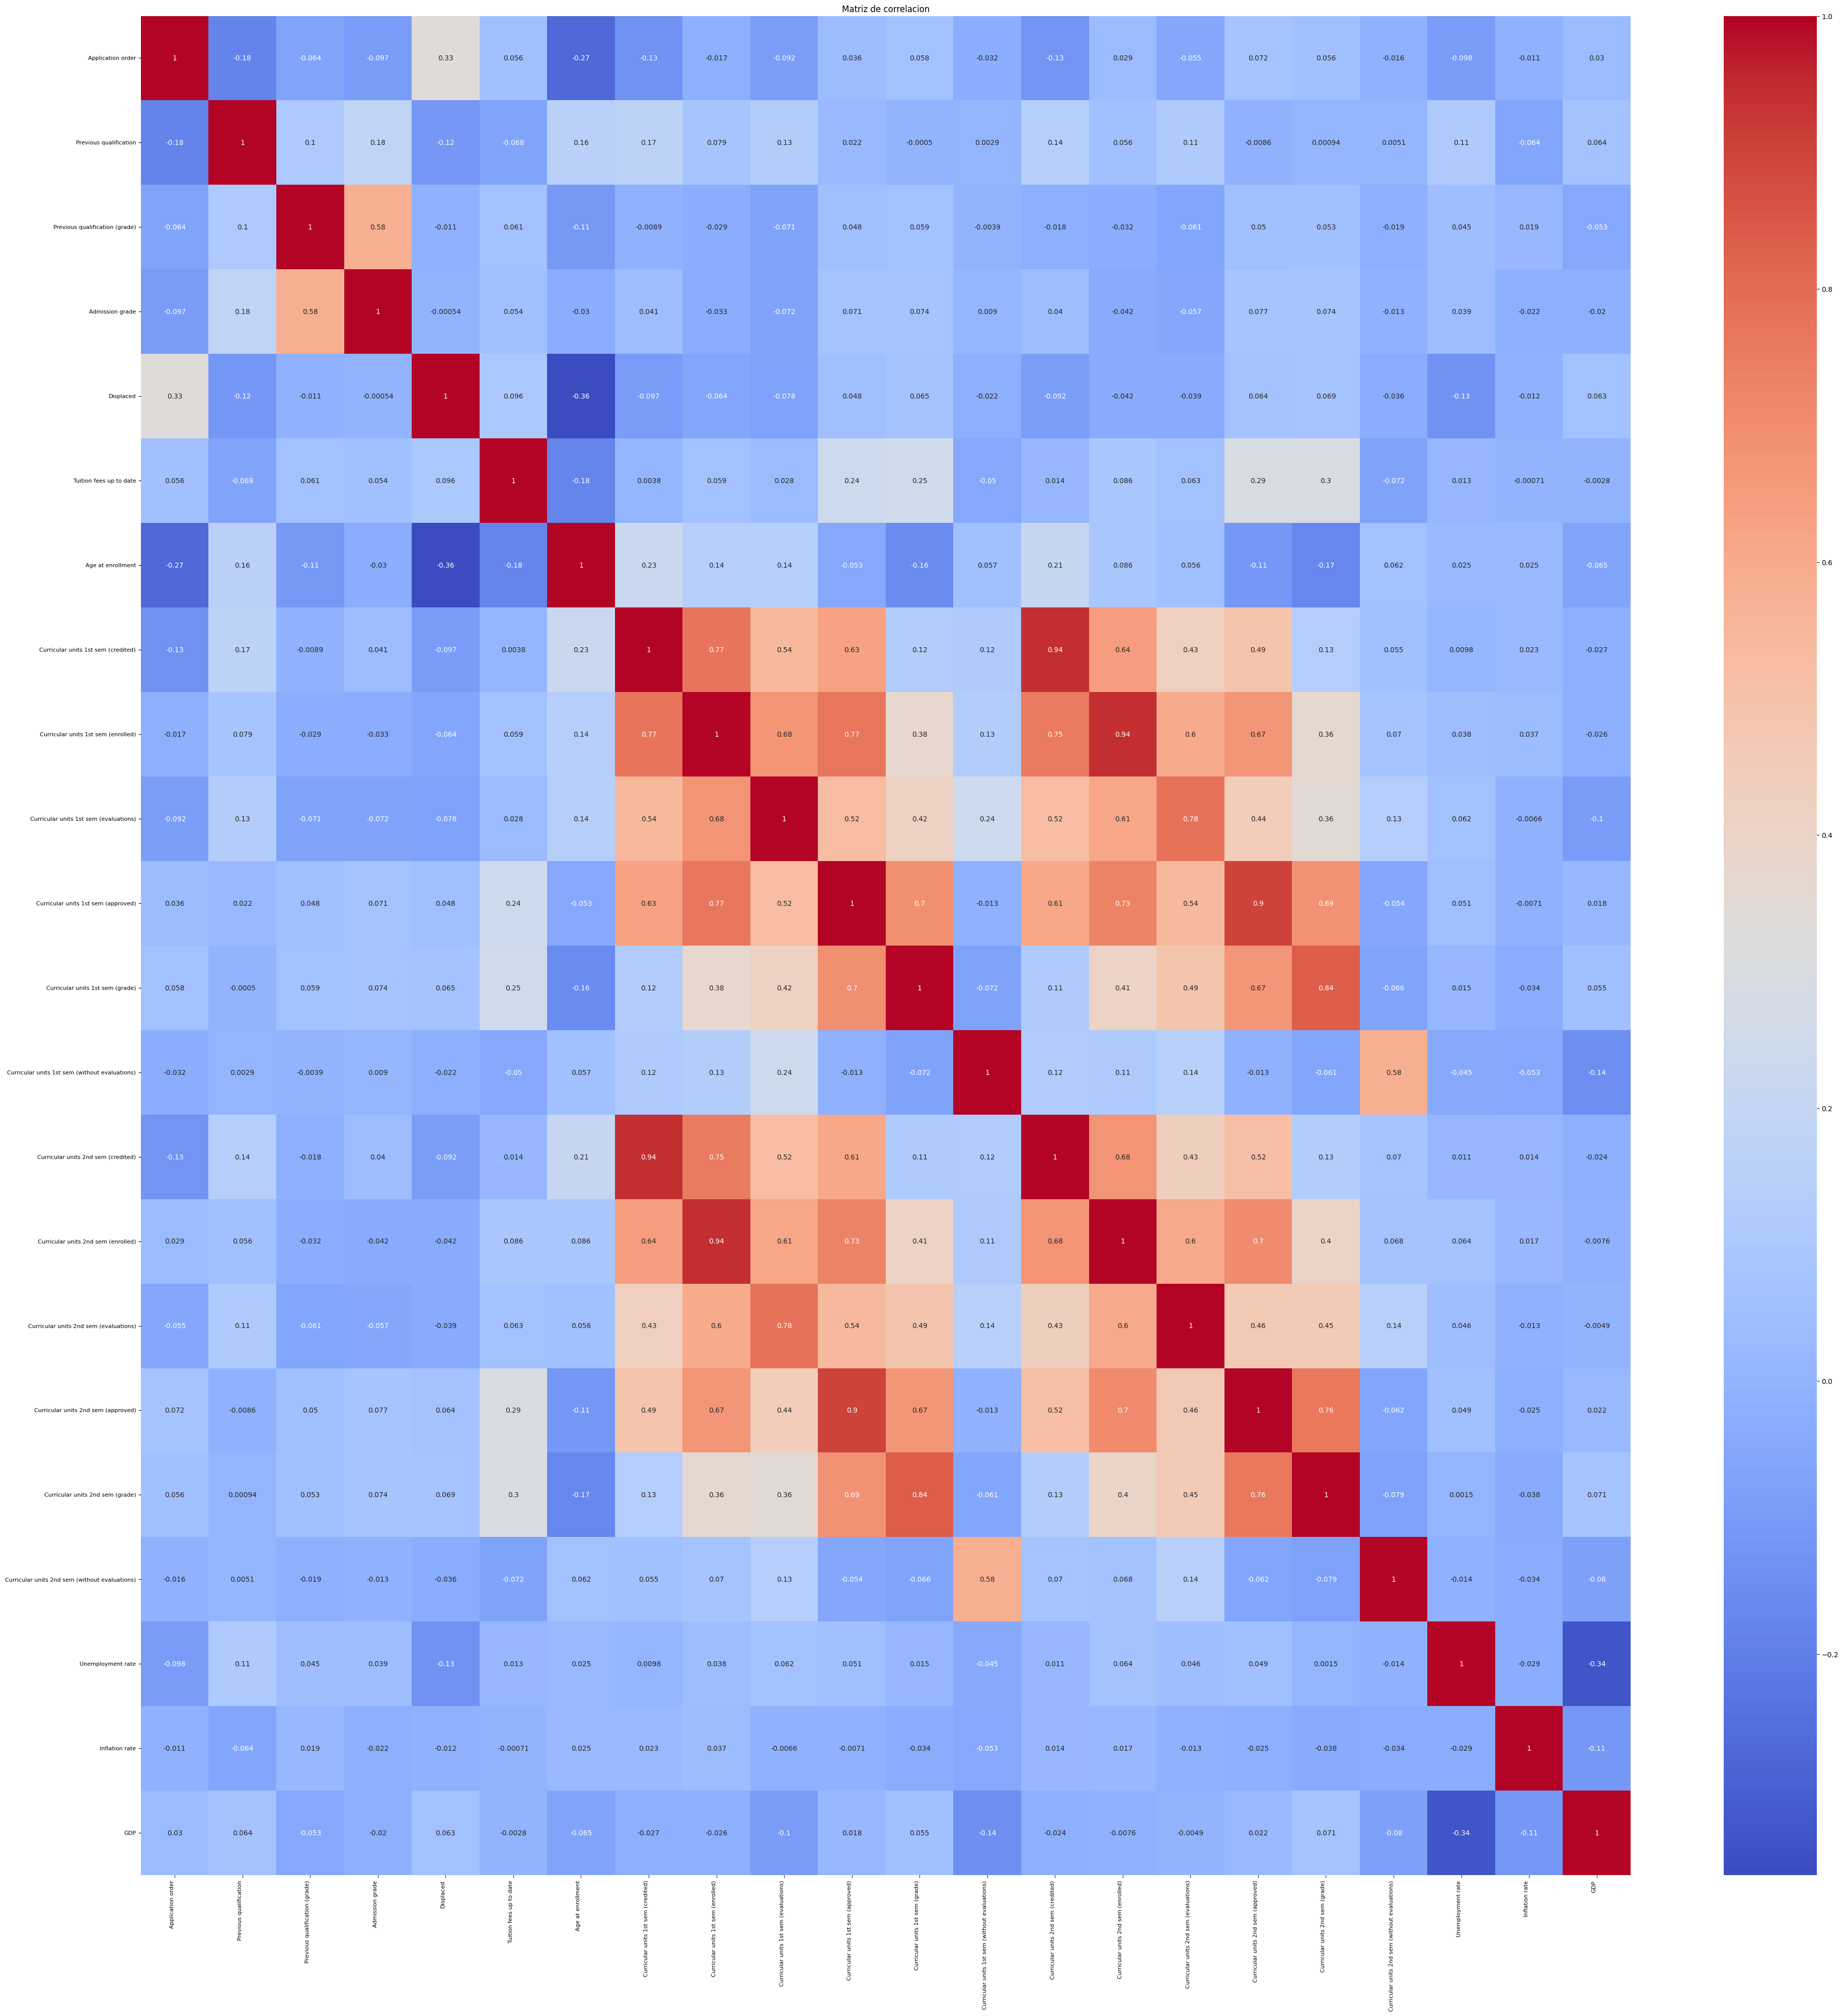

In [ ]:
#Matriz de correlacion
estudiantes.head()

nominal_categorical_columns = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance\t",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Target",
    "Graduado",
    "Educational special needs",
    "Debtor",
    "Gender",
    "Scholarship holder",
    "International"
]
dropped_df=estudiantes.drop(columns=nominal_categorical_columns,axis=1)

#
corr_matrix = dropped_df.corr()


# Create the heatmap
# Get the axes object when creating the heatmap
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Get the current figure and set its size
fig = plt.gcf()
fig.set_size_inches(40, 40) # Increased size (adjust as needed)

# Get the list of column names for the labels
column_names = dropped_df.columns

# Set the x-axis ticks and labels
ax.set_xticks(np.arange(len(column_names)) + 0.5) # Position ticks in the center of the cells
ax.set_xticklabels(column_names, rotation=90, ha='right', fontsize=8) # Rotate labels for readability

# Set the y-axis ticks and labels
ax.set_yticks(np.arange(len(column_names)) + 0.5) # Position ticks in the center of the cells
ax.set_yticklabels(column_names, fontsize=8)

# Automatically adjust plot parameters for a tight layout
plt.tight_layout()

plt.title('Matriz de correlacion')
plt.show()

In [ ]:
def visualize_classifier(model, X, y, ax=None, proba=False):
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(y, pd.Series):
        y = y.values
    ax = ax or plt.gca()

    colors_tab10 = plt.cm.tab10.colors

    for i, y_value in enumerate(reversed(np.unique(y))):
        ax.scatter(X[y==y_value, 0], X[y==y_value, 1], s=30,
                   zorder=3, alpha = 0.5, color = colors_tab10[i])

    ax.axis('tight')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    # ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    aux = pd.DataFrame(data=np.c_[xx.ravel(), yy.ravel()], columns=model.feature_names_in_)
    if proba:
        Z = model.predict_proba(aux)[:, 1].reshape(xx.shape)
    else:
        Z = model.predict(aux).reshape(xx.shape)


    # Create a color plot with the results
    Z = -Z + 1
    ax.pcolormesh(xx,yy,Z,cmap='bwr', vmin=0, vmax=1, alpha=0.2)

    ax.set(xlim=xlim, ylim=ylim)

Frontera de decision

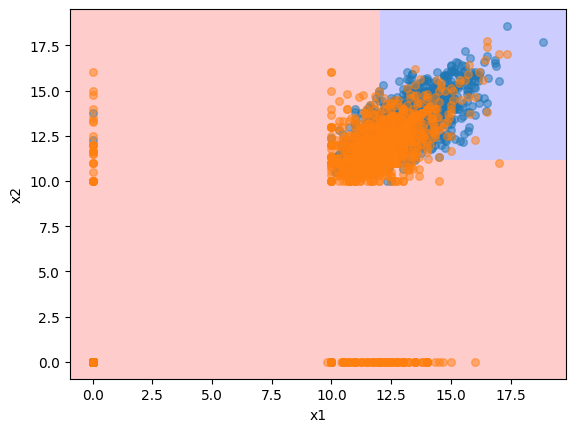

In [ ]:
visualize_classifier(clf, X_train, y_train)

El desempeño del modelo

In [ ]:
from sklearn.metrics import accuracy_score

# Predecimos sobre nuestro set de entrenamieto
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Comaparamos con las etiquetas reales
print("Train:",accuracy_score(y_train_pred,y_train))
print("Test:",accuracy_score(y_test_pred,y_test))

Train: 0.7441860465116279
Test: 0.7311746987951807


4. Definir un primer modelo de Machine Learning con un máximo de 2 (dos) atributos. Recomendamos utilizar las técnicas de preprocesamiento que consideren adecuadas para su dataset, explicando el por qué de los pasos seleccionados. Si se trata de un problema de clasificación, informar el resultado de las métricas elegidas y visualizar la frontera de decisión. Interpretar los resultados.

Regresion logistica

Usamos los mismos atributos que en el punto anterior: los promedios del primer y segundo semestre.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

clf_rl = LogisticRegression(penalty=None)
clf_rl.fit(X_train, y_train)

LogisticRegression(penalty=None)

Medimos el accuracy para comparar con el benchmark. Ambos disminuyen en comparacion al modelo anterior.

In [ ]:
y_train_pred_rl = clf_rl.predict(X_train)
y_test_pred_rl = clf_rl.predict(X_test)
print("Train:",accuracy_score(y_train_pred_rl,y_train))
print("Test:",accuracy_score(y_test_pred_rl,y_test))

Train: 0.7151162790697675
Test: 0.7025602409638554


Visualizamos la frontera de decision

In [ ]:
def visualize_classifier(model, X, y, ax=None, proba = False):
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(y, pd.Series):
        y = y.values
    ax = ax or plt.gca()

    colors_tab10 = plt.cm.tab10.colors

    for i, y_value in enumerate(reversed(np.unique(y))):
        ax.scatter(X[y==y_value, 0], X[y==y_value, 1], s=30,
                   zorder=3, alpha = 0.3, color = colors_tab10[i], label=f'Clase {y_value}')

    ax.axis('tight')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    # ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))

    if proba:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)


    # Create a color plot with the results
    Z = -Z + 1
    ax.pcolormesh(xx,yy,Z,cmap='bwr', vmin = 0, vmax=1, alpha = 0.2)
    ax.contour(xx, yy, Z, colors='k', levels=[0.5], alpha=0.5, linestyles='-')

# Crea la leyenda para los puntos
    handles, labels = axs.get_legend_handles_labels()
    legend1 = axs.legend(handles, labels, loc='upper right')
    axs.add_artist(legend1)  # Añade la primera leyenda para que no se sobreescriba


    ax.set(xlim=xlim, ylim=ylim)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


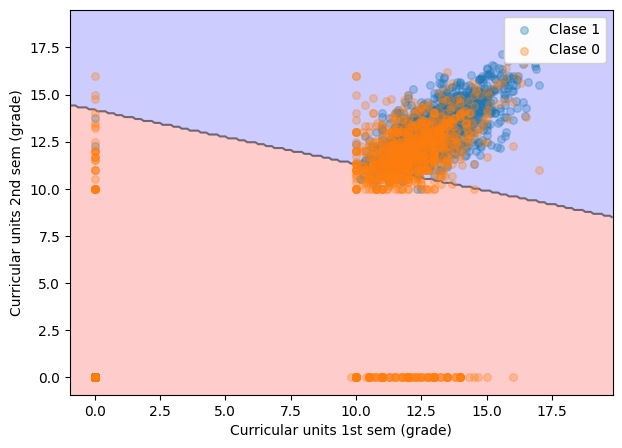

In [ ]:
fig, axs = plt.subplots(1,1, figsize = (7,5))
visualize_classifier(clf_rl, X_train, y_train, ax = axs)
axs.set_xlabel('Atributo 1 - x1')
axs.set_ylabel('Atributo 2 - x2')
plt.xlabel('Curricular units 1st sem (grade)')
plt.ylabel('Curricular units 2nd sem (grade)')

plt.show()

Con escalado de atributos

In [ ]:
#Con escalado de atributos


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf_rl.fit(X_train_scaled, y_train)

LogisticRegression(penalty=None)

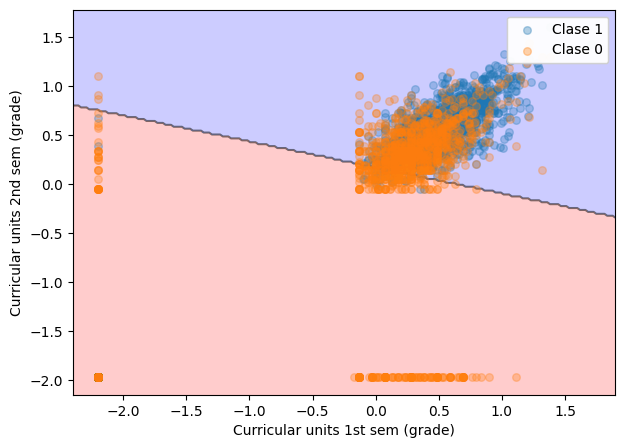

In [ ]:
fig, axs = plt.subplots(1,1, figsize = (7,5))
visualize_classifier(clf_rl, X_train_scaled, y_train, ax = axs)
axs.set_xlabel('Atributo 1 - x1')
axs.set_ylabel('Atributo 2 - x2')
plt.xlabel('Curricular units 1st sem (grade)')
plt.ylabel('Curricular units 2nd sem (grade)')

plt.show()

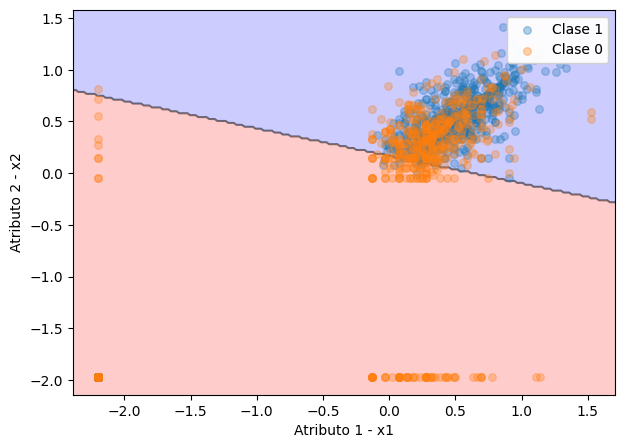

In [ ]:
#Usando los datos de prueba
fig, axs = plt.subplots(1,1, figsize = (7,5))
visualize_classifier(clf_rl, X_test_scaled, y_test, ax = axs)
axs.set_xlabel('Atributo 1 - x1')
axs.set_ylabel('Atributo 2 - x2')
plt.show()

5) Evaluar el primer modelo y abordar las siguientes actividades:

a. Explicar claramente cómo se evaluará el modelo luego de su entrenamiento. Recordar las técnicas vistas en clase.

b. Si se trata de un problema de clasificación, informar el resultado de las métricas elegidas y visualizar la frontera de decisión. Interpretar los resultados.

c. Si se trata de un problema de regresión, informar el resultado de las métricas elegidas y visualizar las predicciones vs las observaciones, y la distribución de los residuos. Interpretar los resultados

In [ ]:
# Comaparamos con las etiquetas reales
print("Accuracy de train del modelo de arbol:",accuracy_score(y_train_pred,y_train),"vs train del modelo de regresion logistica: ",accuracy_score(y_train_pred_rl,y_train))
print("Accuracy de test del modelo de arbol:",accuracy_score(y_test_pred,y_test),"vs test del modelo de regresion logistica: ",accuracy_score(y_test_pred_rl,y_test))

Accuracy de train del modelo de arbol: 0.7441860465116279 vs train del modelo de regresion logistica:  0.7151162790697675
Accuracy de test del modelo de arbol: 0.7311746987951807 vs test del modelo de regresion logistica:  0.7025602409638554


Comparando el accuracy del modelo de regresion logistica con el de arbol de decision (benchmark) en general parece peor

6. Definir un segundo modelo de Machine Learning con todos los atributos que
les parezcan adecuados. Recomendamos utilizar las técnicas de
preprocesamiento que consideren adecuadas para su dataset, explicando el
por qué de los pasos seleccionados.

Defino un modelo de regresion logistica con mas atributos:

In [ ]:
#Agregar mas atributos al modelo de regresion logistica
#Usando escalado:

X = estudiantes[['Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)','Tuition fees up to date']]
y = estudiantes['Graduado']
y = y.map({'No': 0, 'Si': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
scaler = StandardScaler()
X_train_scaled_2 = scaler.fit_transform(X_train)
X_test_scaled_2 = scaler.transform(X_test)

clf_rl_2 = LogisticRegression(penalty=None, max_iter=1000)
clf_rl_2.fit(X_train_scaled_2, y_train)



LogisticRegression(max_iter=1000, penalty=None)

a. Evaluar el modelo utilizando la misma metodología aplicada en el caso
anterior.

In [ ]:
y_train_pred_rl_2 = clf_rl_2.predict(X_train_scaled_2)
y_test_pred_rl_2 = clf_rl_2.predict(X_test_scaled_2)
print("Accuracy en train:",accuracy_score(y_train_pred_rl_2,y_train))
print("Accuracy en test:",accuracy_score(y_test_pred_rl_2,y_test))

Accuracy en train: 0.728359173126615
Accuracy en test: 0.7115963855421686


b. Evaluar el modelo utilizando validación cruzada. Informar e Interpretar
los resultados obtenidos. Comparar con lo realizado en el punto
anterior. Los resultados se pueden presentar en el formato que
consideren más adecuado (texto, tabla, gráfico o combinación de
varios).

In [ ]:
from sklearn.model_selection import cross_val_score
def scores(model,X_tscaled,y_t):
  accuracy_scores = cross_val_score(model, X_tscaled, y_t, cv=5, scoring='accuracy')
  print("Validacion cruzada en exactitud: \n", accuracy_scores)
  print("Media de la exactitud: \n", accuracy_scores.mean())
  auc_scores = cross_val_score(model, X_tscaled, y_t, cv=5, scoring='roc_auc')
  print("Validacion cruzada en AUC-ROC(area bajo la curva roc) scores: \n", auc_scores)
  print("Media AUC-ROC(area bajo la curva roc): \n", auc_scores.mean())

scores(clf_rl_2, X_train_scaled_2, y_train)


Validacion cruzada en exactitud: 
 [0.71935484 0.74313409 0.70113086 0.75121163 0.72213247]
Media de la exactitud: 
 0.727392777111887
Validacion cruzada en AUC-ROC(area bajo la curva roc) scores: 
 [0.82675055 0.85663722 0.80284094 0.85173004 0.83076642]
Media AUC-ROC(area bajo la curva roc): 
 0.8337450363602634


Interpretación de los resultados de validación cruzada:
Compara las medias de accuracy y AUC de la validación cruzada con los valores obtenidos directamente de los conjuntos de train/test.
Una validación cruzada más estable (poca variación entre los folds)
y medias de métricas similares a las de train/test sugieren un modelo más robusto. En este caso los valores de accuracy mejoraron con respecto al modelo anterior

c. Si se utilizó un modelo basado en árboles de decisión, graficar y
analizar la importancia de los atributos. En el caso de haber usado un
regresor logístico o regresión lineal, imprimir y analizar todos los
coeficientes. ¿Qué condiciones se tienen que cumplir para poder
interpretar los coeficientes como importancia de atributos? Si utilizó
otro modelo, investigar si se puede obtener una importancia para cada
atributo.

In [ ]:

def coeficientes(model, coefs):
  print("\n Coeficientes para :",model,"\n")
  for feature, coef in zip(X.columns, coefs):
    print(f"{feature}: {coef:.4f}")

coeficientes("clf_rl", clf_rl.coef_[0])
coeficientes("clf_rl_2", clf_rl_2.coef_[0])



 Coeficientes para : clf_rl 

Curricular units 1st sem (grade): 0.3177
Curricular units 2nd sem (grade): 1.1969

 Coeficientes para : clf_rl_2 

Curricular units 1st sem (grade): 0.3207
Curricular units 2nd sem (grade): 1.0988
Tuition fees up to date: 0.8527


Interpretación de los coeficientes:
En la regresión logística, el signo del coeficiente indica la dirección de la relación entre la característica y la probabilidad de la clase positiva (Graduado='Si' en este caso).
Un coeficiente positivo grande para una característica significa que un aumento en esa característica está asociado con una mayor probabilidad de ser 'Si' (Graduado).
Un coeficiente negativo grande significa que un aumento en la característica está asociado con una menor probabilidad de ser 'Si' (Graduado).
La magnitud del coeficiente indica la fuerza de esta relación, pero la interpretación directa como "importancia de atributos" requiere que las características estén en la misma escala, como lo hemos hecho con StandardScaler.
También es importante considerar la significancia estadística de los coeficientes aunque eso no se calcula automáticamente con este método simple.

8. Analizar y comparar los modelos obtenidos entre sí y con respecto al
benchmark. ¿Qué modelo se elegiría para una posible fase operativo, y por
qué?

Comparación de Accuracy:
Accuracy de train (clf): Train: 0.7441860465116279
Accuracy de test (clf):Test: 0.7311746987951807
Accuracy de train (clf_rl): 0.7151162790697675
Accuracy de test (clf_rl): 0.7025602409638554
Accuracy de train (clf_rl_2): 0.728359173126615
Accuracy de test (clf_rl_2): 0.7115963855421686

Comparación de Curva ROC y AUC:
AUC (clf_rl): 0.800008855344541
AUC (clf_rl_2): 0.8230611336657494


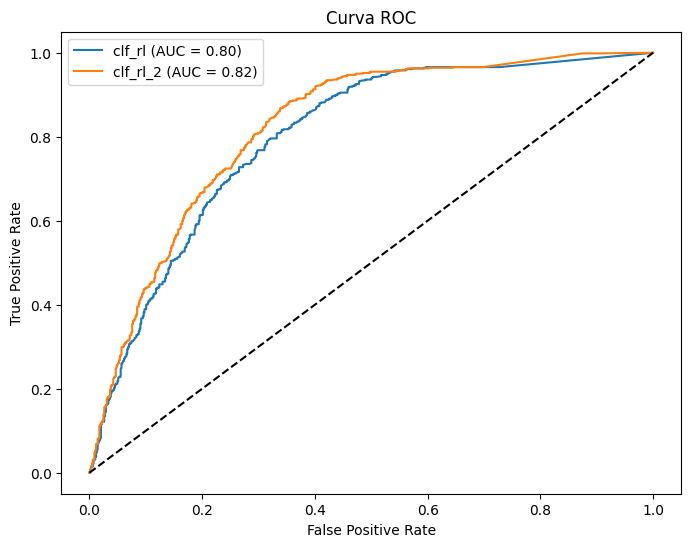

In [ ]:
# Comparación de Accuracy
print("Comparación de Accuracy:")
#print("Accuracy de train (clf):", accuracy_score(y_train, clf.predict(X_train)))
#print("Accuracy de test (clf):", accuracy_score(y_test, clf.predict(X_test)))
print("Accuracy de train (clf): Train: 0.7441860465116279")
print("Accuracy de test (clf):Test: 0.7311746987951807")
print("Accuracy de train (clf_rl):", accuracy_score(y_train, clf_rl.predict(X_train_scaled)))
print("Accuracy de test (clf_rl):", accuracy_score(y_test, clf_rl.predict(X_test_scaled)))
print("Accuracy de train (clf_rl_2):", accuracy_score(y_train, clf_rl_2.predict(X_train_scaled_2)))
print("Accuracy de test (clf_rl_2):", accuracy_score(y_test, clf_rl_2.predict(X_test_scaled_2)))

# Comparación de Curva ROC y AUC
print("\nComparación de Curva ROC y AUC:")

# Para clf_rl
y_prob_rl = clf_rl.predict_proba(X_test_scaled)[:, 1]
fpr_rl, tpr_rl, _ = roc_curve(y_test, y_prob_rl)
auc_rl = auc(fpr_rl, tpr_rl)
print("AUC (clf_rl):", auc_rl)

# Para clf_rl_2
y_prob_rl_2 = clf_rl_2.predict_proba(X_test_scaled_2)[:, 1]
fpr_rl_2, tpr_rl_2, _ = roc_curve(y_test, y_prob_rl_2)
auc_rl_2 = auc(fpr_rl_2, tpr_rl_2)
print("AUC (clf_rl_2):", auc_rl_2)

# Visualización de las curvas ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rl, tpr_rl, label=f'clf_rl (AUC = {auc_rl:.2f})')
plt.plot(fpr_rl_2, tpr_rl_2, label=f'clf_rl_2 (AUC = {auc_rl_2:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

Evaluando solo la metrica de accuracy se ve que mientras el modelo benchmark es mejor con respecto a los otros dos, el modelo de regresión logística con tres variables y con validación cruzada es mejor con respecto al modelo de regresión logística de dos variables sin validación cruzada. El tercer modelo al comparar con el segundo modelo se vé que su curva roc se acerca a una mayor tasa de verdaderos positivos, con un AUC de 0.82 por lo que si bien no supera al modelo benchmark representa una mejora con respecto al modelo de regresión logística de dos variables.